Import thư viện và đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.svm import SVR
import seaborn as sns
import matplotlib.dates as mdates
from datetime import timedelta

# Load data
train_df = pd.read_csv("../Dataset/train1.csv", parse_dates=["date"])
valid_df = pd.read_csv("../Dataset/validation1.csv", parse_dates=["date"])
test_df = pd.read_csv("../Dataset/test1.csv", parse_dates=["date"])

Lựa chọn đặc trưng và target

In [2]:
features = ['daily_tickets', 'daily_used_tickets', 'avg_occupancy', 'unique_films', 'unique_cinemas', 'month', 'quarter', 'day', 'year']
target = 'daily_sales'

X_train = train_df[features].values
y_train = train_df[target].values
X_valid = valid_df[features].values
y_valid = valid_df[target].values
X_test = test_df[features].values
y_test = test_df[target].values

Chuẩn hóa dữ liệu

In [3]:
# Chuẩn hóa
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
X_valid = scaler_X.transform(X_valid)
y_valid = scaler_y.transform(y_valid.reshape(-1, 1)).flatten()
X_test = scaler_X.transform(X_test)
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

Huấn luyện mô hình

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10, 100],
    'gamma': [0.001, 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVR(), param_grid, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_svr = grid_search.best_estimator_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


Đánh giá mô hình

In [19]:
# Dự đoán tập validation
valid_preds_scaled = best_svr.predict(X_valid)
valid_preds = scaler_y.inverse_transform(valid_preds_scaled.reshape(-1, 1)).flatten()
valid_targets = scaler_y.inverse_transform(y_valid.reshape(-1, 1)).flatten()

# Tính metrics cho tập validation
val_mae = mean_absolute_error(valid_targets, valid_preds)
val_rmse = mean_squared_error(valid_targets, valid_preds, squared=False)
val_r2 = r2_score(valid_targets, valid_preds)

print(f"Validation MAE: {val_mae:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")
print(f"Validation R²: {val_r2:.4f}")

# Dự đoán tập test
preds_scaled = best_svr.predict(X_test)
preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Metrics
mae = mean_absolute_error(y_test_original, preds)
rmse = mean_squared_error(y_test_original, preds, squared=False)
r2 = r2_score(y_test_original, preds)

print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.4f}")

Validation MAE: 698449358.38
Validation RMSE: 1257413243.52
Validation R²: 0.7890
Test MAE: 1819321050.85
Test RMSE: 2327878572.65
Test R²: 0.7305


c:\Users\QUYEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\QUYEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


So sánh doanh thu thực tế với dự đoán

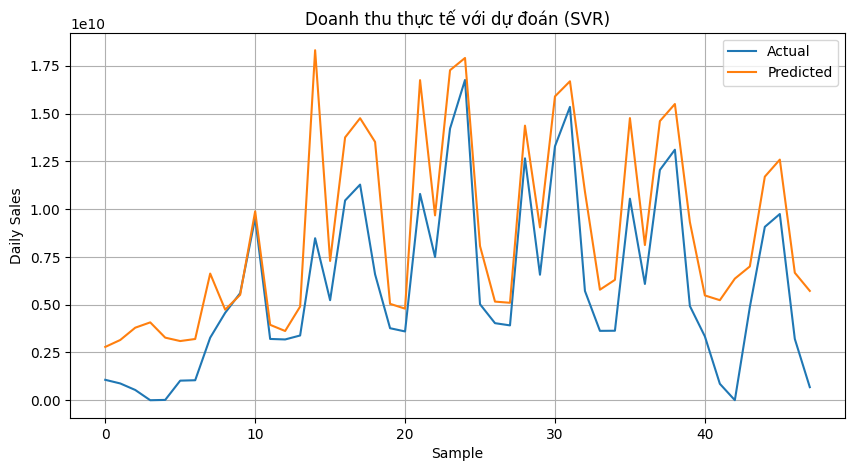

In [17]:
# Vẽ biểu đồ so sánh thực tế và dự đoán
plt.figure(figsize=(10, 5))
plt.plot(y_test_original[:100], label='Actual')
plt.plot(preds[:100], label='Predicted')
plt.legend()
plt.title('Doanh thu thực tế với dự đoán (SVR)')
plt.xlabel('Sample')
plt.ylabel('Daily Sales')
plt.grid(True)
plt.show()

Dự đoán 30 ngày tương lai

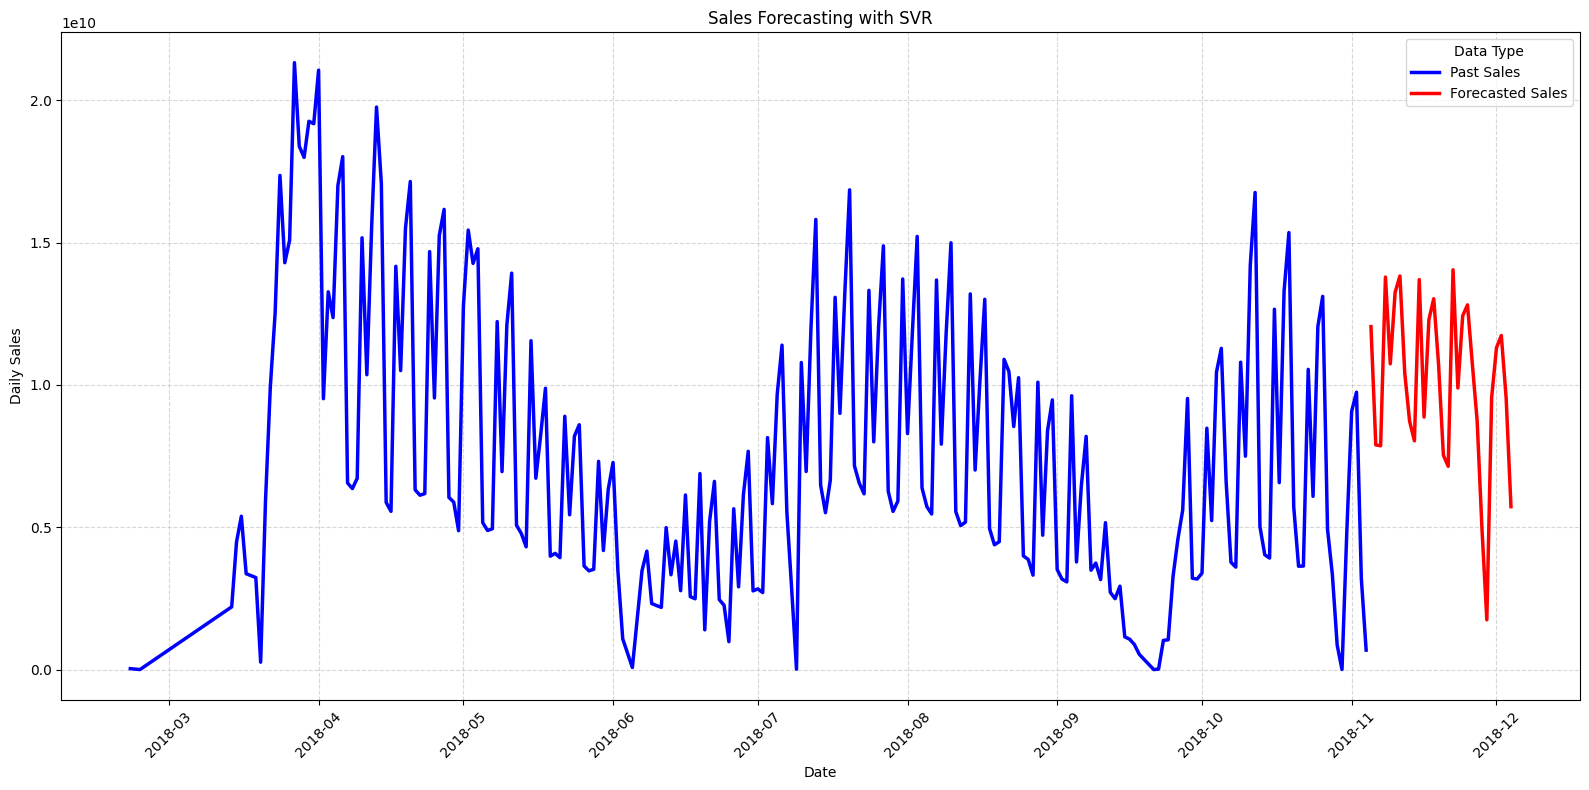

In [14]:
# ===== DỰ ĐOÁN 30 NGÀY TƯ\u01aOC LAI =====
df = pd.read_csv('../Dataset/cinema_daily_sales.csv', parse_dates=['date'])
last_30_days = df.iloc[-30:].copy()
last_date = df['date'].iloc[-1]
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=30)

# Chuẩn bị dữ liệu dự đoán
future_X_raw = last_30_days[features].values
future_X_scaled = scaler_X.transform(future_X_raw)
future_preds_scaled = best_svr.predict(future_X_scaled)
future_sales = scaler_y.inverse_transform(future_preds_scaled.reshape(-1, 1)).flatten()

# Tạo DataFrame dự đoán
future_df = pd.DataFrame({
    'date': future_dates,
    'daily_sales': future_sales,
    'type': 'Forecasted Sales'
})

# Gộp với dữ liệu cũ
df['type'] = 'Past Sales'
combined_df = pd.concat([df[['date', 'daily_sales', 'type']], future_df], ignore_index=True)

# Vẽ biểu đồ
plt.figure(figsize=(16, 8))
sns.lineplot(
    data=combined_df,
    x='date',
    y='daily_sales',
    hue='type',
    style='type',
    dashes=False,
    palette={
        'Past Sales': 'blue',
        'Forecasted Sales': 'red'
    },
    linewidth=2.5
)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.title('Sales Forecasting with SVR')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Data Type')
plt.tight_layout()
plt.show()
